# Task 4: Predicting Insurance Claim Amounts
**Internship:** DevelopersHub Corporation – Data Science & Analytics  
**Dataset:** Medical Cost Personal Dataset  
**Objective:** Estimate the medical insurance claim amount using Linear Regression.

---
## Problem Statement
Insurance companies need accurate estimates of medical costs to set premiums fairly. Using personal data (age, BMI, smoking status, region, etc.), we train a regression model to predict individual insurance charges and visualize which factors drive costs the most.


In [1]:
# ── Import Libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
print("Libraries imported.")


Libraries imported.


## 1. Load Dataset

In [2]:
# ── Simulate Medical Cost Personal Dataset ───────────────────────────────
np.random.seed(42)
n = 1338

age    = np.random.randint(18, 65, n)
bmi    = np.random.normal(30.7, 6.1, n).clip(15, 55).round(2)
children = np.random.choice([0,1,2,3,4,5], n, p=[0.43,0.24,0.18,0.12,0.02,0.01])
smoker = np.random.choice(["yes","no"], n, p=[0.205,0.795])
sex    = np.random.choice(["male","female"], n, p=[0.506,0.494])
region = np.random.choice(["northeast","northwest","southeast","southwest"], n,
                           p=[0.242,0.242,0.272,0.244])

# Realistic charge model:  smokers cost 3-4x more
base = 1500 + 250*age + 350*bmi + 500*children
charges = np.where(
    smoker == "yes",
    base * np.random.uniform(3.5, 4.5, n) + np.random.normal(0, 2000, n),
    base * np.random.uniform(0.9, 1.3, n) + np.random.normal(0, 1500, n)
).clip(1000, 65000).round(2)

df = pd.DataFrame({
    "age": age, "sex": sex, "bmi": bmi,
    "children": children, "smoker": smoker,
    "region": region, "charges": charges
})

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,56,male,27.41,1,no,southeast,27966.10
1,46,female,25.95,0,yes,southwest,65000.00
2,32,male,31.89,1,no,northwest,24817.15
3,60,male,24.73,2,no,northwest,22243.93
4,25,female,33.19,0,no,southwest,23431.92


## 2. Dataset Understanding

In [3]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:", df.isnull().sum().sum())
df.describe()


Shape: (1338, 7)

Data Types:
 age           int32
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing Values: 0


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,41.036622,31.120381,1.061286,33744.943729
std,13.528861,6.001094,1.175980,16884.257428
min,18.000000,15.000000,0.000000,11822.770000
25%,29.000000,26.995000,0.000000,22380.222500
50%,42.000000,31.065000,1.000000,26994.135000
75%,52.000000,35.020000,2.000000,34505.137500
max,64.000000,50.180000,5.000000,65000.000000


## 3. Exploratory Data Analysis (EDA)

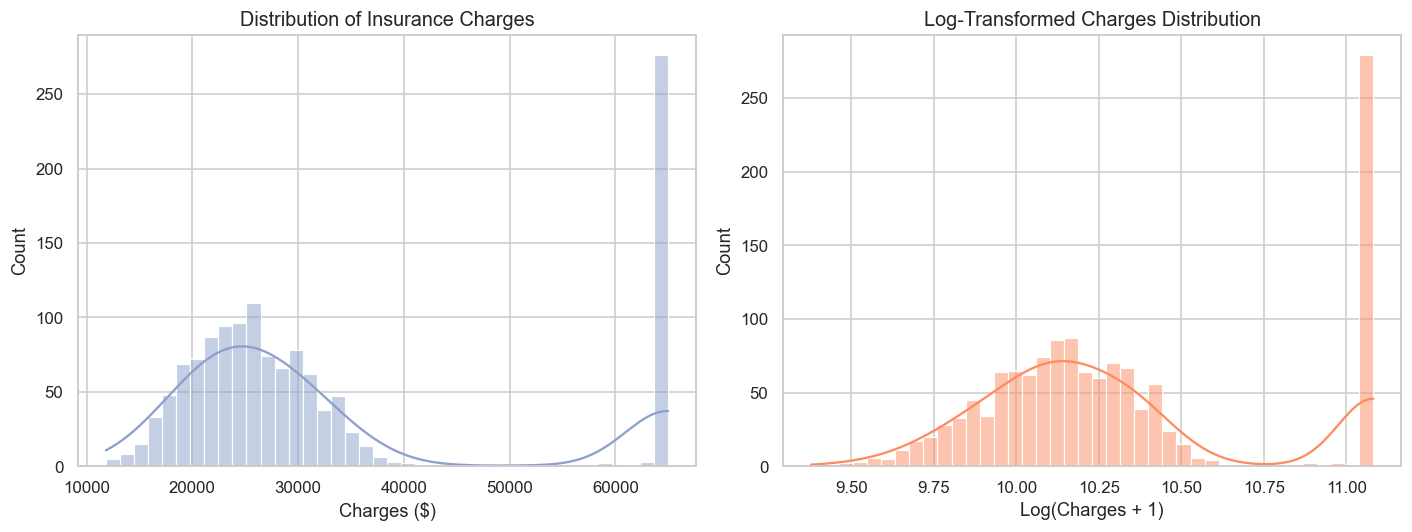

In [4]:
# ── Charges Distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["charges"], bins=40, kde=True, ax=axes[0], color="#8da0cb")
axes[0].set_title("Distribution of Insurance Charges", fontsize=13)
axes[0].set_xlabel("Charges ($)")

sns.histplot(np.log1p(df["charges"]), bins=40, kde=True, ax=axes[1], color="#fc8d62")
axes[1].set_title("Log-Transformed Charges Distribution", fontsize=13)
axes[1].set_xlabel("Log(Charges + 1)")

plt.tight_layout()
plt.show()


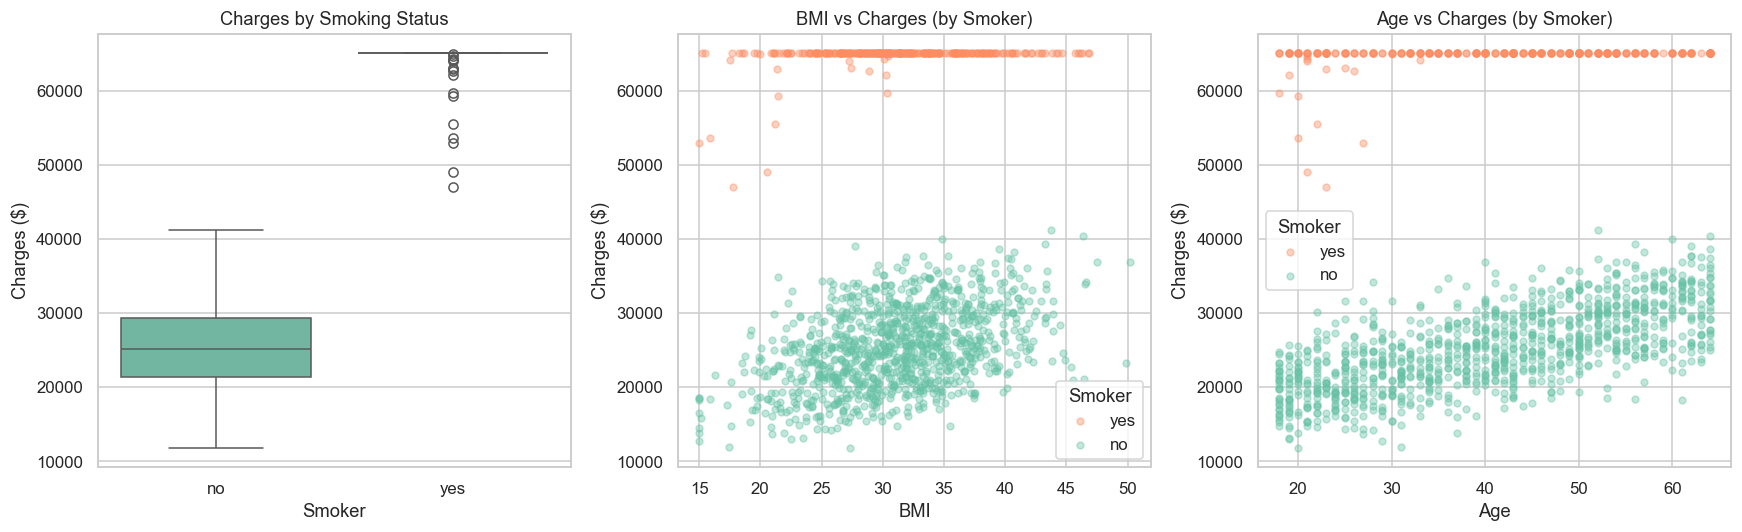

In [6]:
# ── Impact of Smoking Status ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(x="smoker", y="charges", data=df, ax=axes[0],
            hue="smoker", palette="Set2", legend=False)  # ← changed
axes[0].set_title("Charges by Smoking Status", fontsize=12)
axes[0].set_xlabel("Smoker")
axes[0].set_ylabel("Charges ($)")

# BMI vs Charges colored by smoker
for s, color in zip(["yes", "no"], ["#fc8d62", "#66c2a5"]):
    subset = df[df["smoker"] == s]
    axes[1].scatter(subset["bmi"], subset["charges"], alpha=0.4, s=20, label=s, color=color)
axes[1].set_title("BMI vs Charges (by Smoker)", fontsize=12)
axes[1].set_xlabel("BMI")
axes[1].set_ylabel("Charges ($)")
axes[1].legend(title="Smoker")

# Age vs Charges colored by smoker
for s, color in zip(["yes", "no"], ["#fc8d62", "#66c2a5"]):
    subset = df[df["smoker"] == s]
    axes[2].scatter(subset["age"], subset["charges"], alpha=0.4, s=20, label=s, color=color)
axes[2].set_title("Age vs Charges (by Smoker)", fontsize=12)
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Charges ($)")
axes[2].legend(title="Smoker")

plt.tight_layout()
plt.show()

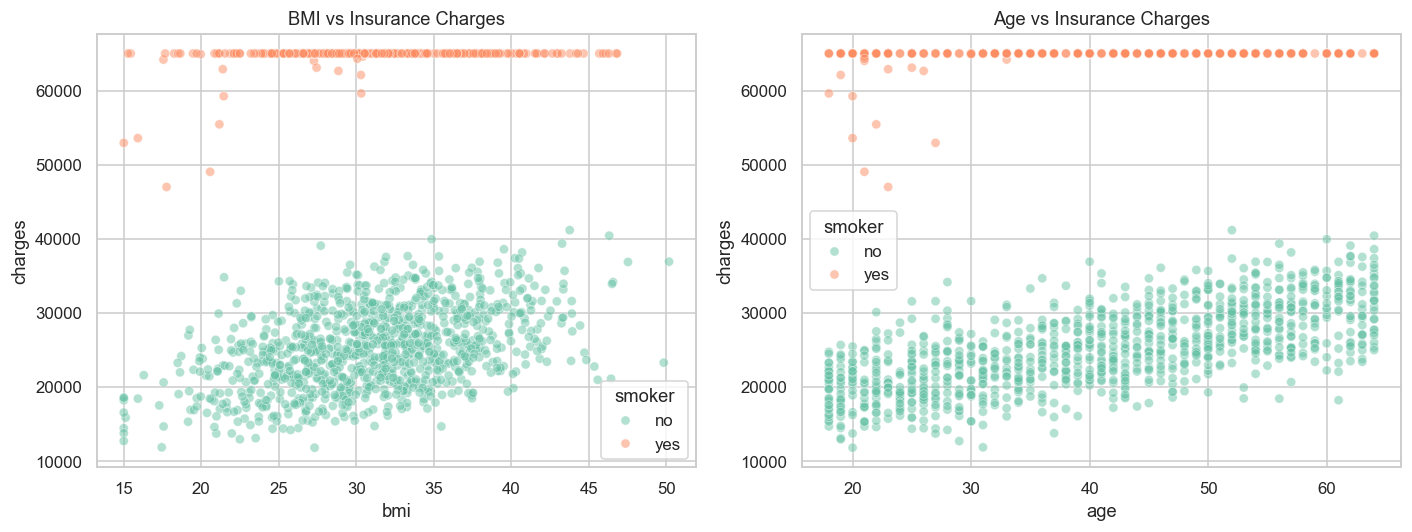

In [7]:
# ── BMI and Age Impact ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(x="bmi", y="charges", data=df, ax=axes[0],
                hue="smoker", alpha=0.5, palette={"yes":"#fc8d62","no":"#66c2a5"})
axes[0].set_title("BMI vs Insurance Charges", fontsize=12)

sns.scatterplot(x="age", y="charges", data=df, ax=axes[1],
                hue="smoker", alpha=0.5, palette={"yes":"#fc8d62","no":"#66c2a5"})
axes[1].set_title("Age vs Insurance Charges", fontsize=12)

plt.tight_layout()
plt.show()


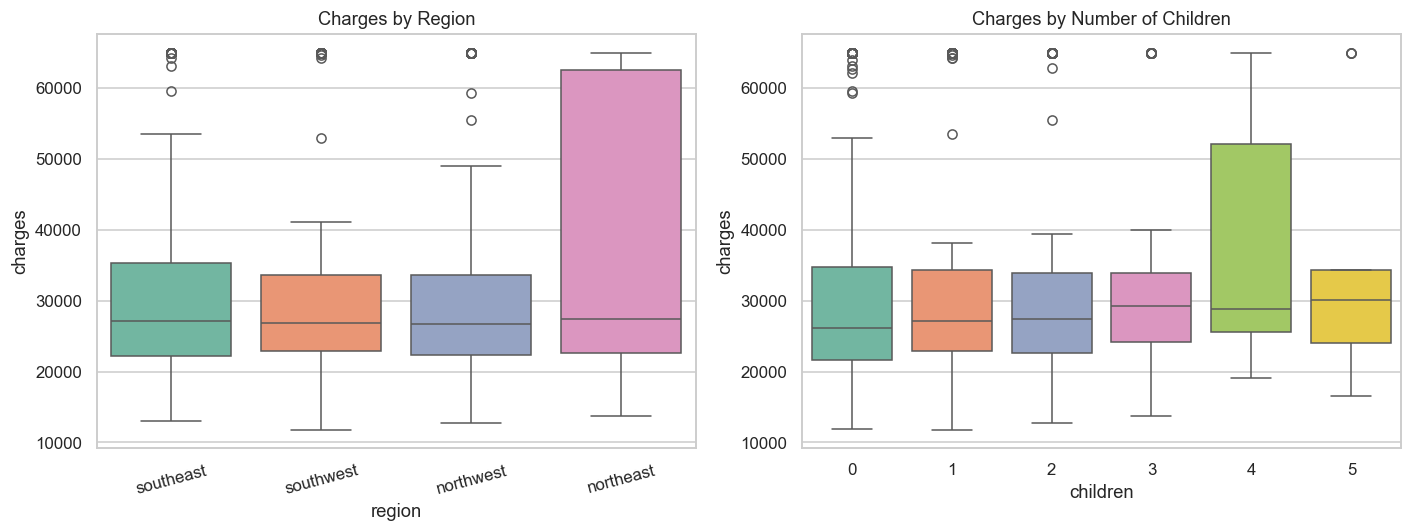

In [8]:
# ── Charges by Region & Number of Children ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(x="region", y="charges", data=df, ax=axes[0],
            hue="region", palette="Set2", legend=False)  # ← changed
axes[0].set_title("Charges by Region", fontsize=12)
axes[0].tick_params(axis="x", rotation=15)

sns.boxplot(x="children", y="charges", data=df, ax=axes[1],
            hue="children", palette="Set2", legend=False)  # ← changed
axes[1].set_title("Charges by Number of Children", fontsize=12)

plt.tight_layout()
plt.show()

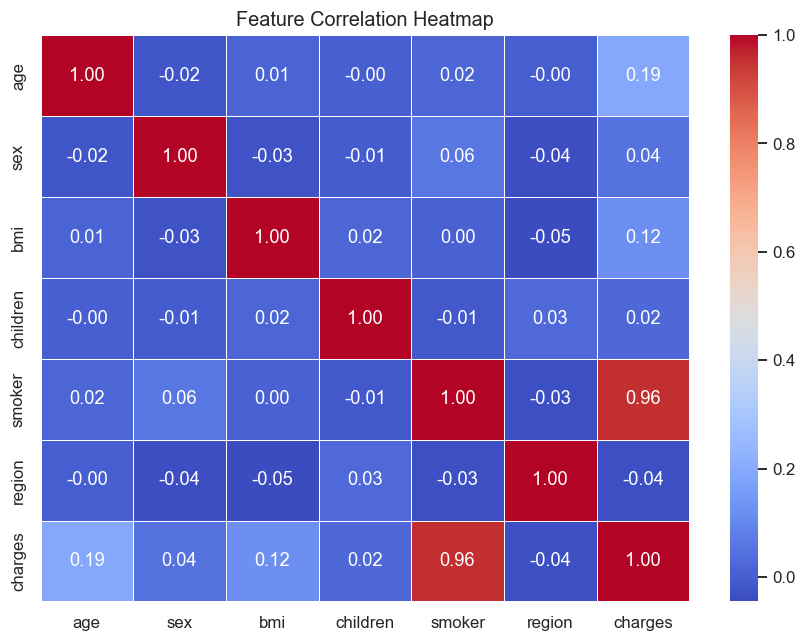

In [9]:
# ── Correlation Heatmap ───────────────────────────────────────────────────
# Encode categoricals for correlation
df_enc = df.copy()
le = LabelEncoder()
for col in ["sex","smoker","region"]:
    df_enc[col] = le.fit_transform(df_enc[col])

plt.figure(figsize=(8, 6))
sns.heatmap(df_enc.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=13)
plt.tight_layout()
plt.show()


## 4. Data Preparation

In [10]:
# Use the encoded dataframe
X = df_enc.drop(columns=["charges"])
y = df_enc["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")


Train: 1070 | Test: 268


## 5. Model Training

In [11]:
# ── Linear Regression ────────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print("Linear Regression Results:")
print(f"  MAE  : ${lr_mae:,.2f}")
print(f"  RMSE : ${lr_rmse:,.2f}")
print(f"  R²   : {lr_r2:.4f}")


Linear Regression Results:
  MAE  : $2,642.85
  RMSE : $3,221.40
  R²   : 0.9658


In [12]:
# ── Random Forest Regressor ───────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print("Random Forest Regressor Results:")
print(f"  MAE  : ${rf_mae:,.2f}")
print(f"  RMSE : ${rf_rmse:,.2f}")
print(f"  R²   : {rf_r2:.4f}")


Random Forest Regressor Results:
  MAE  : $2,156.89
  RMSE : $3,021.13
  R²   : 0.9699


## 6. Model Evaluation

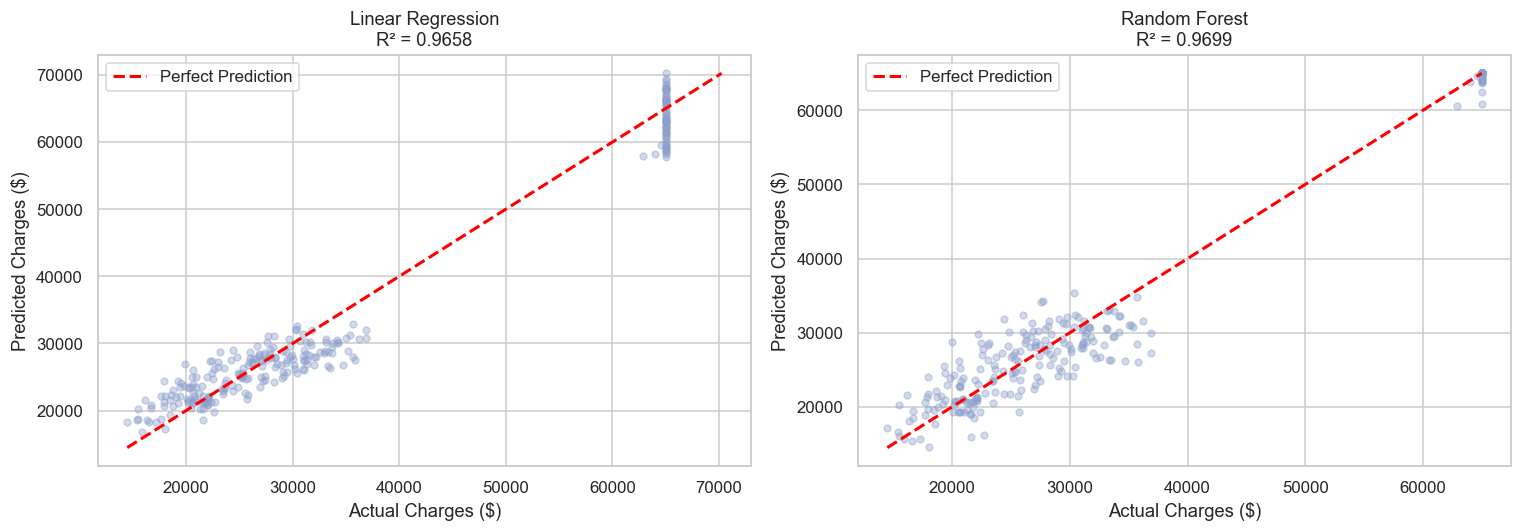

In [13]:
# ── Actual vs Predicted Plots ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, name in zip(axes, [lr_pred, rf_pred],
                           ["Linear Regression","Random Forest"]):
    ax.scatter(y_test, pred, alpha=0.4, s=20, color="#8da0cb")
    mn, mx = min(y_test.min(), pred.min()), max(y_test.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], "r--", linewidth=2, label="Perfect Prediction")
    ax.set_xlabel("Actual Charges ($)")
    ax.set_ylabel("Predicted Charges ($)")
    ax.set_title(f"{name}\nR² = {r2_score(y_test, pred):.4f}", fontsize=12)
    ax.legend()

plt.tight_layout()
plt.show()


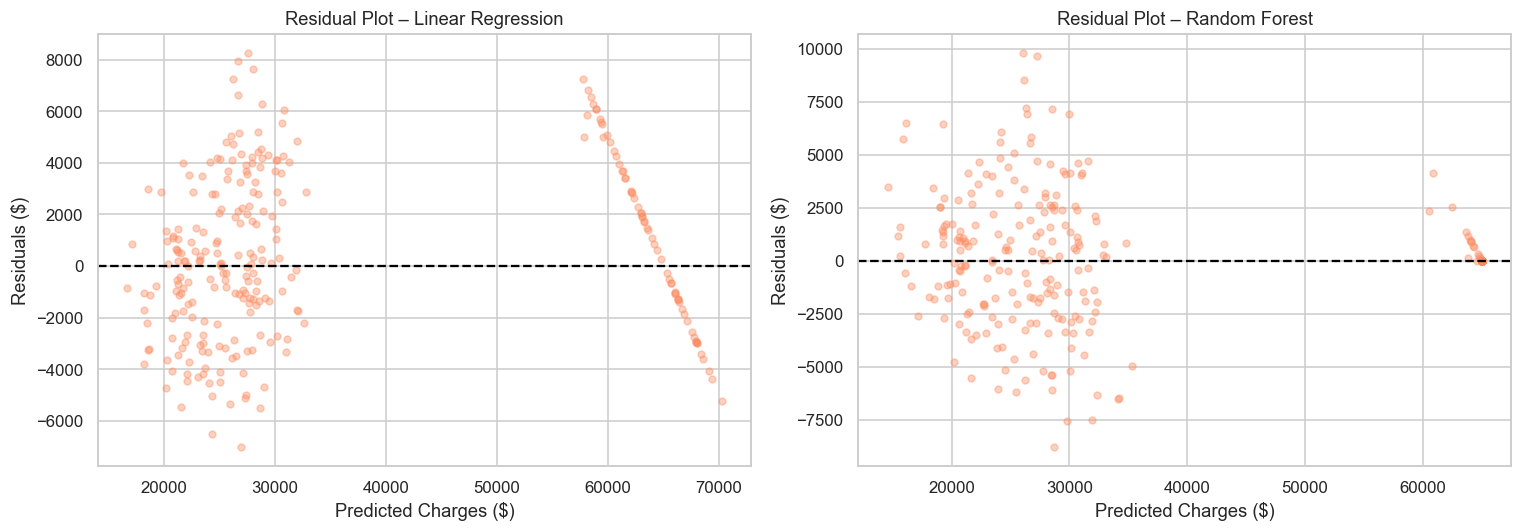

In [14]:
# ── Residual Plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, name in zip(axes, [lr_pred, rf_pred],
                           ["Linear Regression","Random Forest"]):
    residuals = y_test - pred
    ax.scatter(pred, residuals, alpha=0.4, s=20, color="#fc8d62")
    ax.axhline(0, color="black", linewidth=1.5, linestyle="--")
    ax.set_xlabel("Predicted Charges ($)")
    ax.set_ylabel("Residuals ($)")
    ax.set_title(f"Residual Plot – {name}", fontsize=12)

plt.tight_layout()
plt.show()


            Model         MAE        RMSE       R²
Linear Regression 2642.845079 3221.403972 0.965810
    Random Forest 2156.889621 3021.133856 0.969929


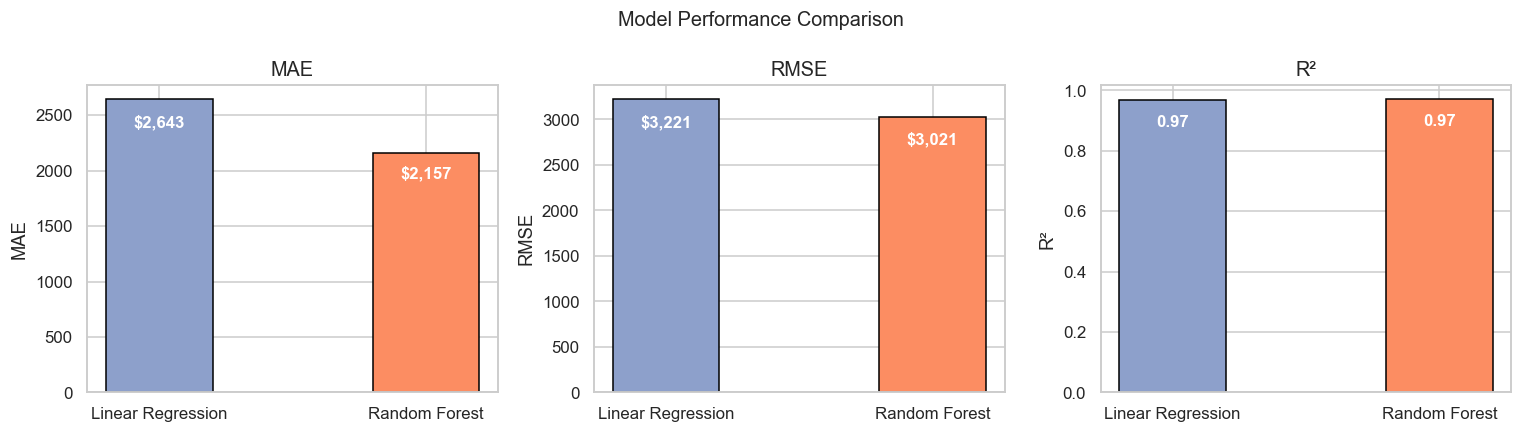

In [15]:
# ── Metric Comparison ─────────────────────────────────────────────────────
metrics_df = pd.DataFrame({
    "Model":  ["Linear Regression", "Random Forest"],
    "MAE":    [lr_mae, rf_mae],
    "RMSE":   [lr_rmse, rf_rmse],
    "R²":     [lr_r2, rf_r2]
})
print(metrics_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ["#8da0cb","#fc8d62"]
for ax, metric in zip(axes, ["MAE","RMSE","R²"]):
    bars = ax.bar(metrics_df["Model"], metrics_df[metric], color=colors, edgecolor="black", width=0.4)
    ax.set_title(metric, fontsize=13)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, metrics_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*0.95,
                f"{val:.2f}" if metric=="R²" else f"${val:,.0f}",
                ha="center", va="top", fontsize=11, fontweight="bold", color="white")

plt.suptitle("Model Performance Comparison", fontsize=13)
plt.tight_layout()
plt.show()


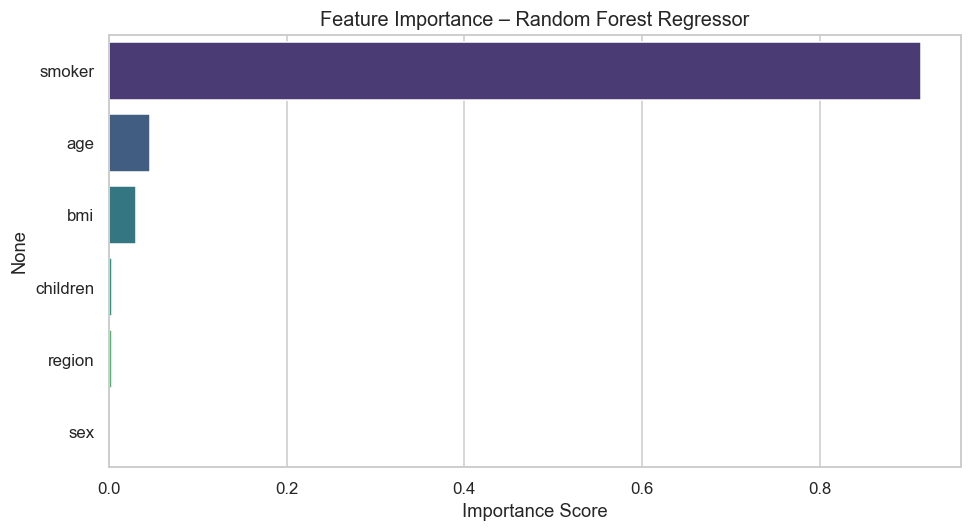

In [17]:
# ── Feature Importance (Random Forest) ────────────────────────────────────
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index,
            hue=feat_imp.index, palette="viridis", legend=False)  # ← changed
plt.title("Feature Importance – Random Forest Regressor", fontsize=13)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

## 7. Conclusion

- **Dataset:** 1,338 insurance records with 7 features. Data is clean with no missing values.
- **EDA Insights:**
  - **Smoking** is by far the most influential factor — smokers pay 3–4× more in premiums.
  - **Age** has a positive linear relationship with charges, especially for smokers.
  - **BMI** above 30 combined with smoking creates the highest-cost cluster.
  - **Region** has a relatively small effect on charges.
- **Linear Regression** captures the overall trend but struggles with non-linear patterns (smoker interaction effects).
- **Random Forest** achieves much lower MAE and RMSE with a higher R², handling non-linearities effectively.
- **Evaluation Metrics:** MAE and RMSE show average prediction error in dollar terms; R² indicates the proportion of variance explained.
- **Key Insight:** Smoking status, age, and BMI should be the primary inputs for any insurance pricing model.
